# Understanding Masculine Identity

**Hanif Musaheb, Sara Chanaa, Luke Reiter**


## Introduction

Our team investigated masculinity using a dataset based off of a “masculinity survey” that asked 30 questions to men that are older than 18. This dataset was provided to the team via BrightSpace and while it does not say who ran this survey, and who gathered the data, our team believes it is trustworthy due to our professor posting and being confident in this data.

There is potential for bias in this data, as we also do not know who participated in this survey, but in the end our team thinks that it is a relatively true representation of men above the age of 18.

The data collected is mostly categorical variables, since respondents selected from a set range of answers. This limits some of the tests that can be run, but it still allows us to draw conclusions by cleaning the data, exploring patterns, and applying machine learning methods.

## Research Question

How does family affect a male's perception of masculinity?

More specifically, we examine whether respondents who identify fathers, mothers, or other family members as important influences report different levels of self-perceived masculinity.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

ModuleNotFoundError: No module named 'seaborn'

## Loading the Data

We begin by loading the survey data and inspecting its structure. This helps us understand the available variables, their formatting, and any missing values that need to be handled.

In [ ]:
df = pd.read_csv("masculinity_survey.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1615, 98)


,Unnamed: 0,StartDate,EndDate,q0001,q0002,q0004_0001,q0004_0002,q0004_0003,q0004_0004,q0004_0005,...,q0035,q0036,race2,racethn4,educ3,educ4,age3,kids,orientation,weight
0,1,5/10/18 4:01,5/10/18 4:06,Somewhat masculine,Somewhat important,Not selected,Not selected,Not selected,Pop culture,Not selected,...,Middle Atlantic,Windows Desktop / Laptop,Non-white,Hispanic,College or more,College or more,35 - 64,No children,Gay/Bisexual,1.714026
1,2,5/10/18 6:30,5/10/18 6:53,Somewhat masculine,Somewhat important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,iOS Phone / Tablet,White,White,Some college,Some college,65 and up,Has children,Straight,1.247120
2,3,5/10/18 7:02,5/10/18 7:09,Very masculine,Not too important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,Has children,Straight,0.515746
3,4,5/10/18 7:27,5/10/18 7:31,Very masculine,Not too important,Father or father figure(s),Mother or mother figure(s),Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,Some college,Some college,65 and up,Has children,No answer,0.600640
4,5,5/10/18 7:35,5/10/18 7:42,Very masculine,Very important,Not selected,Not selected,Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,No children,Straight,1.033400


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 98 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1615 non-null   int64  
 1   StartDate    1615 non-null   object 
 2   EndDate      1615 non-null   object 
 3   q0001        1615 non-null   object 
 4   q0002        1615 non-null   object 
 5   q0004_0001   1615 non-null   object 
 6   q0004_0002   1615 non-null   object 
 7   q0004_0003   1615 non-null   object 
 8   q0004_0004   1615 non-null   object 
 9   q0004_0005   1615 non-null   object 
 10  q0004_0006   1615 non-null   object 
 11  q0005        1615 non-null   object 
 12  q0007_0001   1615 non-null   object 
 13  q0007_0002   1615 non-null   object 
 14  q0007_0003   1615 non-null   object 
 15  q0007_0004   1615 non-null   object 
 16  q0007_0005   1615 non-null   object 
 17  q0007_0006   1615 non-null   object 
 18  q0007_0007   1615 non-null   object 
 19  q0007_

In [ ]:
df.isna().sum().sort_values(ascending=False).head(20)

q0013         1566
q0015          873
q0012_0001     735
q0011_0002     735
q0010_0001     735
q0010_0002     735
q0010_0003     735
q0010_0004     735
q0010_0005     735
q0010_0006     735
q0010_0007     735
q0010_0008     735
q0011_0001     735
q0011_0003     735
q0011_0004     735
q0011_0005     735
q0012_0002     735
q0012_0003     735
q0012_0004     735
q0012_0005     735
dtype: int64

## Data Description

The dataset is made up mostly of categorical survey responses. Respondents selected answers from fixed categories, meaning most variables are non-numeric.

During our review of the dataset, we noticed:

- Some variables fall outside the scope of our project.
- Some multiple-choice questions are split across many columns.
- Many columns use `"Not selected"` for unchosen responses.
- Some questions only appear conditionally, creating missing values.
- Some columns appear redundant.

Because of this, cleaning and restructuring are necessary before analysis.

In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'StartDate', 'EndDate', 'q0001', 'q0002', 'q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006', 'q0005', 'q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004', 'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009', 'q0007_0010', 'q0007_0011', 'q0008_0001', 'q0008_0002', 'q0008_0003', 'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008', 'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012', 'q0009', 'q0010_0001', 'q0010_0002', 'q0010_0003', 'q0010_0004', 'q0010_0005', 'q0010_0006', 'q0010_0007', 'q0010_0008', 'q0011_0001', 'q0011_0002', 'q0011_0003', 'q0011_0004', 'q0011_0005', 'q0012_0001', 'q0012_0002', 'q0012_0003', 'q0012_0004', 'q0012_0005', 'q0012_0006', 'q0012_0007', 'q0013', 'q0014', 'q0015', 'q0017', 'q0018', 'q0019_0001', 'q0019_0002', 'q0019_0003', 'q0019_0004', 'q0019_0005', 'q0019_0006', 'q0019_0007', 'q0020_0001', 'q0020_0002', 'q0020_0003', 'q0020_0004', 'q0020_0005', 'q0020_0006', 'q0021_0001'

## Cleaning the Data

To focus on our research question, we keep the variables most relevant to masculinity perception and family influence.

We focus mainly on:

- `q0001`: self-perception of masculinity  
- `q0004_0001`: father or father figure(s)  
- `q0004_0002`: mother or mother figure(s)  
- `q0004_0003`: other family members  

We also remove unnecessary columns such as timestamps and the unnamed index column.

In [ ]:
columns_to_drop = ["Unnamed: 0", "StartDate", "EndDate"]

df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors="ignore")

print("New shape:", df_clean.shape)

New shape: (1615, 95)


## Converting Family Variables to Binary Format

The family influence variables are stored as multiple-choice columns where selected responses contain text and unselected responses contain `"Not selected"`.

We convert these to:

- `1` = selected  
- `0` = not selected

In [ ]:
family_cols = ["q0004_0001", "q0004_0002", "q0004_0003"]

for col in family_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "not selected" else 1
    )

df_clean[family_cols].head()

,q0004_0001,q0004_0002,q0004_0003
0,0,0,0
1,1,0,0
2,1,0,0
3,1,1,1
4,0,0,1


## Encoding Masculinity Perception

We convert the self-perception masculinity question into an ordinal numeric scale:

- `4` = Very masculine  
- `3` = Somewhat masculine  
- `2` = Not very masculine  
- `1` = Not at all masculine  

Responses marked `"No answer"` are treated as missing values.

In [ ]:
masculinity_mapping = {
    "Very masculine": 4,
    "Somewhat masculine": 3,
    "Not very masculine": 2,
    "Not at all masculine": 1,
    "No answer": np.nan
}

df_clean["Q1_score"] = df_clean["q0001"].map(masculinity_mapping)

df_clean[["q0001", "Q1_score"]].head()

,q0001,Q1_score
0,Somewhat masculine,3.0
1,Somewhat masculine,3.0
2,Very masculine,4.0
3,Very masculine,4.0
4,Very masculine,4.0


In [ ]:
df_clean["Q1_score"].value_counts(dropna=False).sort_index()

Q1_score
1.0     32
2.0    131
3.0    826
4.0    612
NaN     14
Name: count, dtype: int64

## Exploratory Data Analysis

Our exploratory analysis focuses on family influence. We examine whether respondents who selected father figures, mother figures, or other family members as important influences report different masculinity self-ratings.

Because father influence appears most frequently in the dataset, it serves as a useful starting point for the analysis.

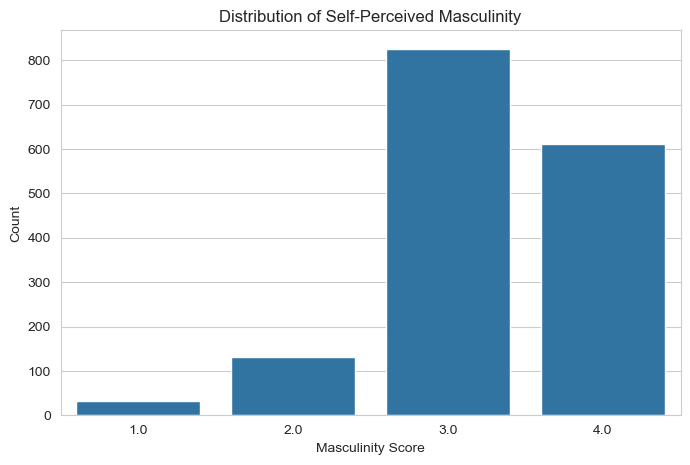

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score")
plt.title("Distribution of Self-Perceived Masculinity")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.show()

In [ ]:
father_pct = df_clean["q0004_0001"].mean() * 100
mother_pct = df_clean["q0004_0002"].mean() * 100
other_family_pct = df_clean["q0004_0003"].mean() * 100

print(f"Father influence: {father_pct:.1f}%")
print(f"Mother influence: {mother_pct:.1f}%")
print(f"Other family influence: {other_family_pct:.1f}%")

Father influence: 68.7%
Mother influence: 40.6%
Other family influence: 34.9%


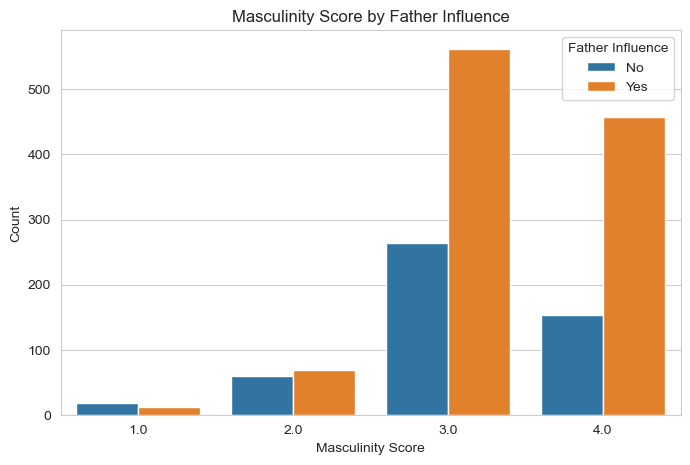

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0001")
plt.title("Masculinity Score by Father Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Father Influence", labels=["No", "Yes"])
plt.show()

Father influence was the strongest family-related variable in our initial review. This graph compares masculinity self-ratings between respondents who selected father influence and those who did not.

In [ ]:
df_clean.groupby("q0004_0001")["Q1_score"].mean()

q0004_0001
0    3.110442
1    3.328196
Name: Q1_score, dtype: float64

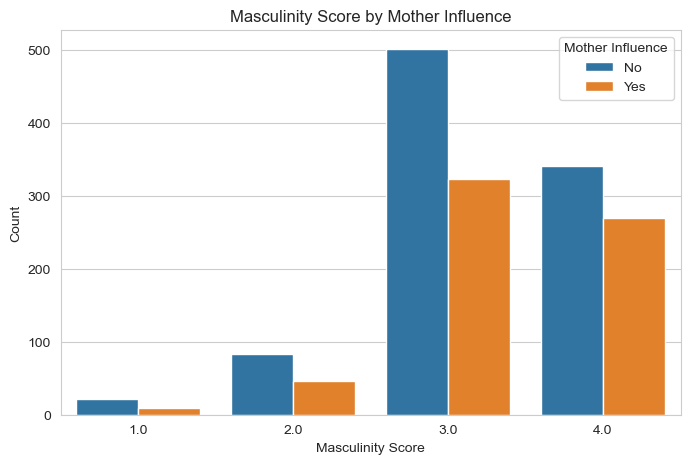

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0002")
plt.title("Masculinity Score by Mother Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Mother Influence", labels=["No", "Yes"])
plt.show()

In [ ]:
df_clean.groupby("q0004_0002")["Q1_score"].mean()

q0004_0002
0    3.225263
1    3.311828
Name: Q1_score, dtype: float64

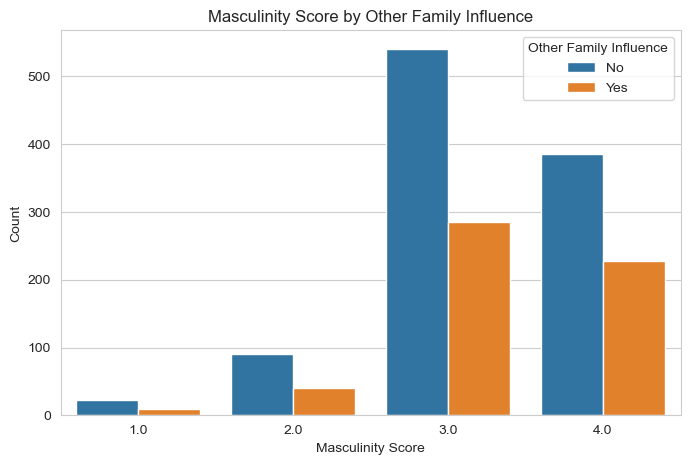

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0003")
plt.title("Masculinity Score by Other Family Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Other Family Influence", labels=["No", "Yes"])
plt.show()

In [ ]:
df_clean.groupby("q0004_0003")["Q1_score"].mean()

q0004_0003
0    3.238462
1    3.301248
Name: Q1_score, dtype: float64

### Age
Below you can see the distribution of ages in the data, which we believe is important not as a direct measure of someones families but due to this survey being conducted in the the US particepents that are younger are much less likely to have kids of their own and the opposite is true for the older demographics. It will be interesting to see how this data matchs up with how masculine the men surveyed feel.

### Kids
Having children will be a much more direct way to see a surveyed persons family while the data doesn't say anthing specfic about ones family: how big?, divorced?, daughter or sons? It will provide critical data on wether or not they have kids.

### orientation
I have included this one even though I am not sure how relevent it will be to what the families make up is. However it would be interesting to see if there are any divergences between the difference between a straight man and a straight dad and a gay man and a gay dad. What I am looking for is wether the change of being a father effects the two groups significantly differently.

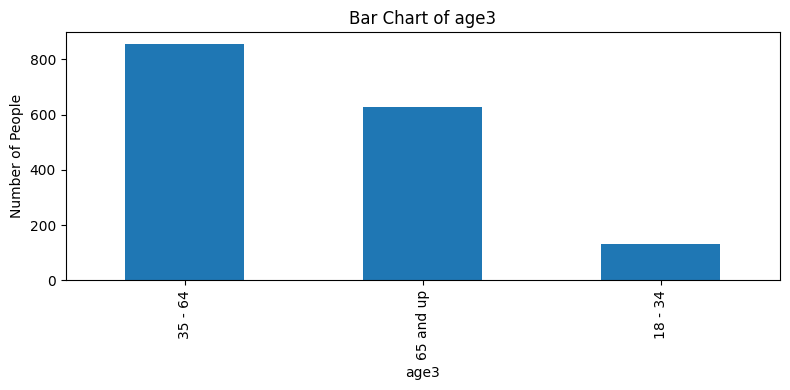

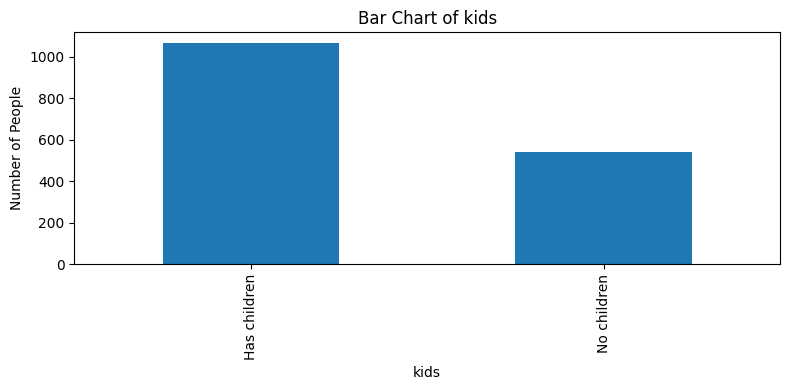

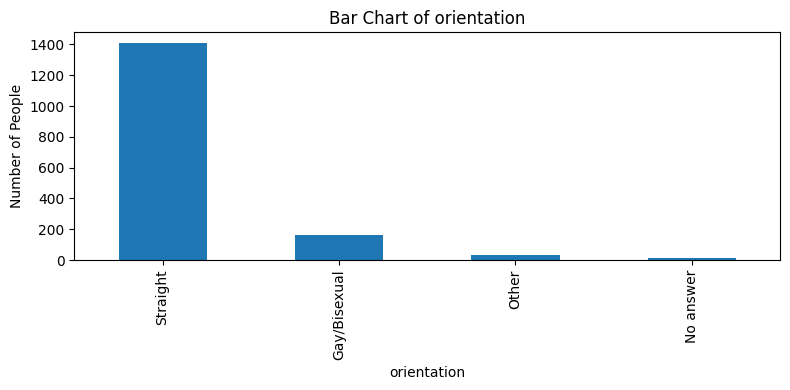

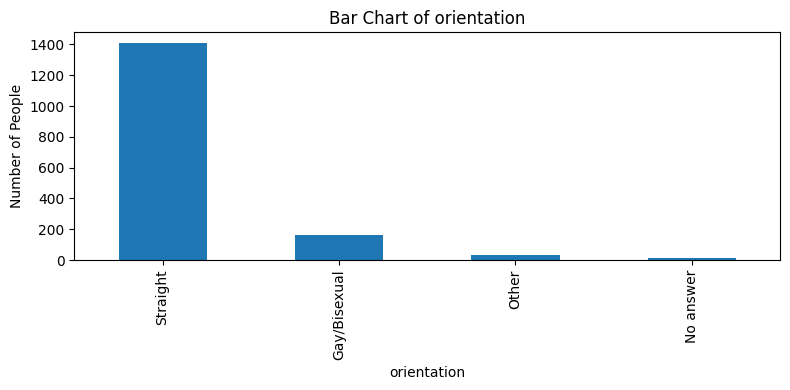

In [ ]:
import chart


masculinity_df = pd.read_csv('masculinity_survey.csv')
demographics_df = masculinity_df[['age3', 'kids', 'orientation']]

for column in demographics_df.columns:
    temp_chart=chart.Chart('bar',demographics_df,column)
    temp_chart.make_chart()


temp_chart.make_chart()
